In [1]:
import os 
os.chdir('/Users/franciscegoat/Zermelo')
import matplotlib.pyplot as plt
import numpy as np
import src.utils.metrics as mt
from src.models.coefficients import f_1, compute_f_exact, u_exact
from config.parameters import Params
from src.models.fd.solver import Solveur_Zermelo




params = Params(
    r = .5,
    R = np.sqrt(2),
    kappa = .1,
    vs = .5,
    a = .2,
    sig_x = .5,
    sig_y = .2,
    X_min = -2.0,
    X_max = 2.0,
    Y_min = -2.0,
    Y_max = 2.0
)

N_list = [10*2**(k) for k in range (7)]

# Notebook des résultats: 
## 1. Différences finies : 

In [2]:


errors, times, e = mt.convergence_fd(params, N_list, f_1)

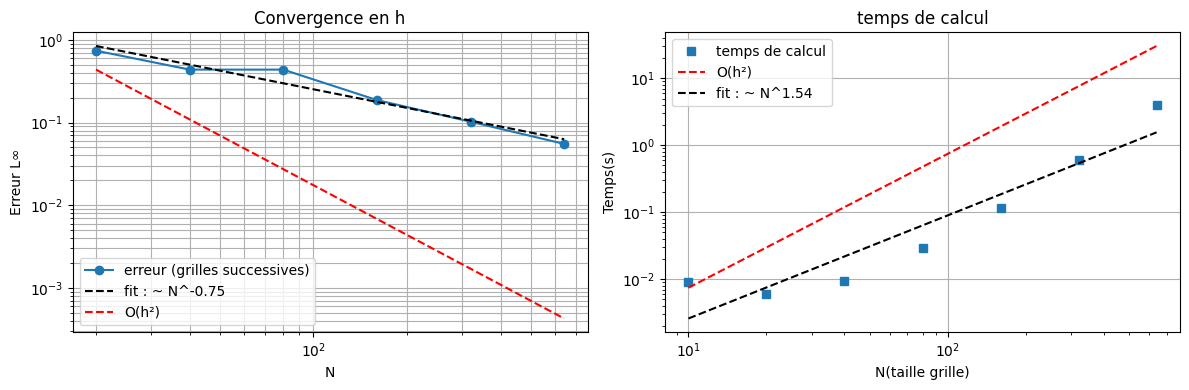

[0.009217023849487305, 0.006095170974731445, 0.009278297424316406, 0.029082059860229492, 0.11600208282470703, 0.6042299270629883, 3.9382522106170654]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
N_list = np.asarray(N_list)
ax = axes[0]
ax.loglog(N_list[1:], errors, 'o-', label='erreur (grilles successives)')
p, logC = np.polyfit(np.log(N_list[1:]), np.log(errors),1 )
C = np.exp(logC)
ax.loglog(N_list[1:], C * N_list[1:]**p, 'k--', label=f'fit : ~ N^{p:.2f}')
ax.loglog(N_list[1:], [errors[1] * (N_list[1]/N_list[i+1])**2 for i in range(len(errors))],
              'r--', label='O(h²)')
ax.set_xlabel('N'); ax.set_ylabel('Erreur L∞')
ax.set_title('Convergence en h')
ax.legend(); ax.grid(True, which='both')
    
ax2 = axes[1]
ax2.loglog(N_list, times, 's', label = 'temps de calcul')
ax2.set_xlabel('N(taille grille)')
ax2.set_ylabel('Temps(s)')
ax2.set_title('temps de calcul')

ax2.grid(True)
p, logC = np.polyfit(np.log(N_list[:]), np.log(times),1 )
C = np.exp(logC)
ax2.loglog(N_list[:], C* N_list[:] **2,'r--', label='O(h²)')
ax2.loglog(N_list[:], C * N_list[:]**p, 'k--', label=f'fit : ~ N^{p:.2f}') 
ax2.legend()
plt.tight_layout()
plt.show()
fig.savefig('results/convergence_fd.pdf', dpi = 300)

print(times)

In [4]:


errors, times, errex = mt.convergence_fd(params, N_list, compute_f_exact, u_exacte = u_exact)

[0.006398439407348633, 0.007745027542114258, 0.011689901351928711, 0.035720109939575195, 0.1535332202911377, 0.7865002155303955, 5.101903915405273]


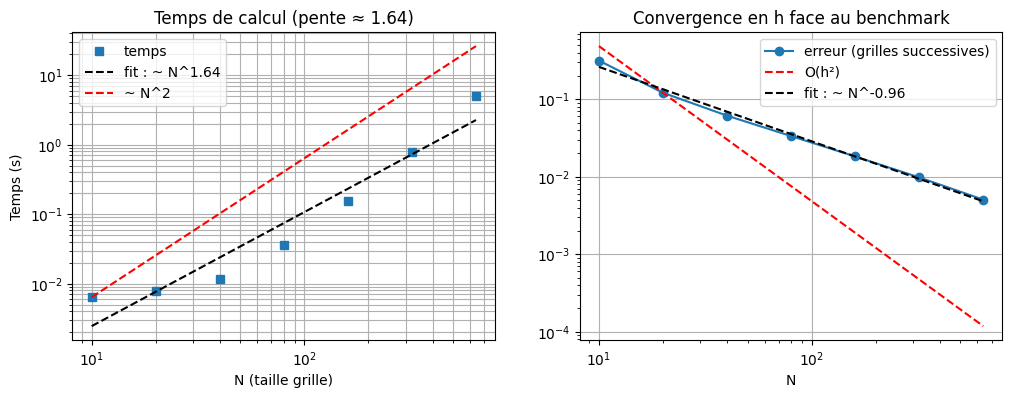

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
N_list = np.asarray(N_list)
    
ax2 = axes[0]
ax2.loglog(N_list, times, 's', label='temps')

# --- AJOUT : fit log-log pour estimer l'ordre T(N) ~ C N^p
p, logC = np.polyfit(np.log(N_list), np.log(times), 1)  # log(t)=p log(N)+logC
C = np.exp(logC)
ax2.loglog(N_list, C * N_list**p, 'k--', label=f'fit : ~ N^{p:.2f}')

# option: ancrer une droite "ronde" (ex: p_arrondi) pour lecture immédiate
p_round = int(np.round(p))
C_round = times[0] / (N_list[0]**p_round)
ax2.loglog(N_list, C_round * N_list**p_round, 'r--', label=f'~ N^{p_round}')

ax2.set_xlabel('N (taille grille)')
ax2.set_ylabel('Temps (s)')
ax2.set_title(f'Temps de calcul (pente ≈ {p:.2f})')
ax2.grid(True, which='both')
ax2.legend()

ax3 = axes[1]
ax3.loglog(N_list[:], errex[:], 'o-', label='erreur (grilles successives)')
#ax3.loglog(N_list[:], [errex[1] * (N_list[1]/N_list[i])**1 for i in range(len(errex))],'k--', label='O(h¹)')
ax3.loglog(N_list[:], [errex[1] * (N_list[1]/N_list[i])**2 for i in range(len(errex))],
              'r--', label='O(h²)')
p, logC = np.polyfit(np.log(N_list), np.log(errex), 1)  # log(t)=p log(N)+logC
C = np.exp(logC)
ax3.loglog(N_list, C * (N_list**p), 'k--', label=f'fit : ~ N^{p:.2f}')
ax3.set_xlabel('N'); ax.set_ylabel('Erreur L∞')
ax3.set_title('Convergence en h face au benchmark')
ax3.legend(); ax.grid(True, which='both')
ax3.grid(True)


fig.savefig('results/Convergence_benchmark_fd.pdf',bbox_inches = 'tight', dpi = 300)
print (times)

In [6]:
epochs = N_list
l_moy, times,e, mode = mt.convergence_pinn_epochs(params, f_1, epoch_list = epochs)

Convergence PINN : calcul de la solution de référence par FD sur une grille de 1000x1000 points...
Temps de calcul de la solution de référence : 16.51 secondes
Entrainement du PINN...


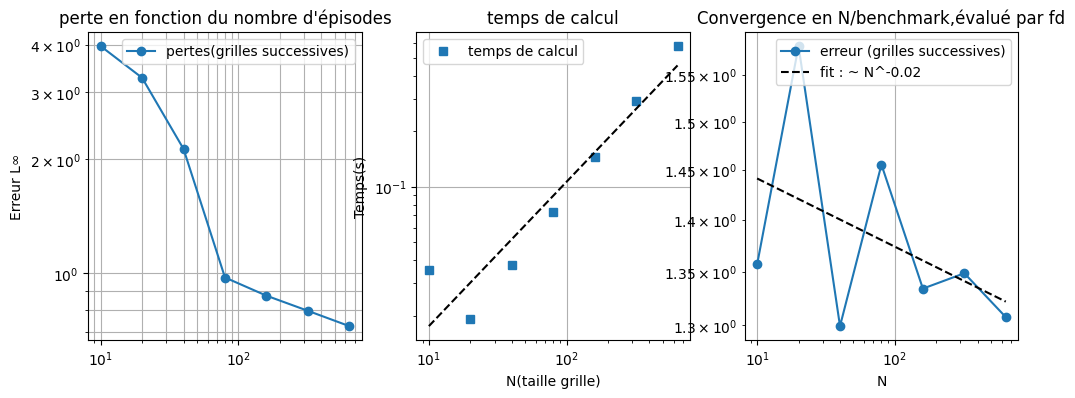

In [8]:
fig, axes = plt.subplots(1, 3, figsize = (12,4))

ax = axes[0]
ax.loglog(N_list[:], l_moy, 'o-', label='pertes(grilles successives)')
ax.set_title("perte en fonction du nombre d'épisodes")
ax.legend(); ax.grid(True, which='both')
    
ax2 = axes[1]
ax2.loglog(N_list, times, 's', label = "temps de calcul" )
ax2.set_xlabel('N(taille grille)')
ax2.set_ylabel('Temps(s)')
ax2.set_title('temps de calcul')
ax2.legend()
p, logC = np.polyfit(np.log(epochs), np.log(times), 1)  # log(t)=p log(N)+logC
C = np.exp(logC)
ax2.loglog(epochs, C * epochs**p, 'k--', label=f'fit : ~ N^{p:.2f}')
ax2.grid(True)

if e is not None : 
    ax3 = axes[2]
    ax3.loglog(epochs[:], e[:], 'o-', label='erreur (grilles successives)')
    #ax3.loglog(epochs[:], [e[1] * (epochs[1]/epochs[i])**1 for i in range(len(e))],'r--', label='O(h¹)')
    #ax.loglog(epochs[:], [e[1] * (epochs[1]/epochs[i])**2 for i in range(len(e))],'r--', label='O(h²)')
    p, logC = np.polyfit(np.log(epochs), np.log(e), 1)  # log(t)=p log(N)+logC
    C = np.exp(logC)
    ax3.loglog(epochs, C * epochs**p, 'k--', label=f'fit : ~ N^{p:.2f}')
    ax3.set_xlabel('N'); ax.set_ylabel('Erreur L∞')
    ax3.set_title(f"Convergence en N/benchmark,évalué par {mode}")
    ax3.legend(); ax.grid(True, which='both')
    ax3.grid(True)
fig.savefig("results/Convergence_pinn_epoch.pdf", dpi = 300)

In [10]:
epochs = [10**k for k in range (6)]
l_moy, times,e, mode = mt.convergence_pinn_epochs(params, compute_f_exact, u_ref = u_exact, epoch_list = epochs)

Entrainement du PINN...


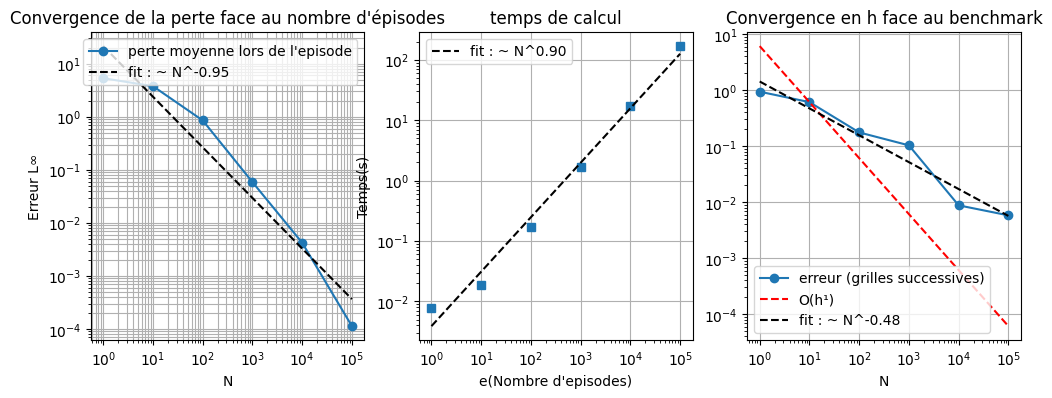

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes[0]
ax.loglog(epochs[:], l_moy, 'o-', label="perte moyenne lors de l'episode")
ax.set_xlabel('N'); ax.set_ylabel('perte')
ax.set_title("Convergence de la perte face au nombre d'épisodes")

p, logC = np.polyfit(np.log(epochs), np.log(l_moy), 1)  # log(t)=p log(N)+logC
C = np.exp(logC)
ax.loglog(epochs, C * epochs**p, 'k--', label=f'fit : ~ N^{p:.2f}')

ax.legend(); ax.grid(True, which='both')
    
ax2 = axes[1]
ax2.loglog(epochs[:], times, 's')
ax2.set_xlabel("e(Nombre d'episodes)")
ax2.set_ylabel('Temps(s)')
p, logC = np.polyfit(np.log(epochs), np.log(times), 1)  # log(t)=p log(N)+logC
C = np.exp(logC)
ax2.loglog(epochs, C * epochs**p, 'k--', label=f'fit : ~ N^{p:.2f}')
ax2.set_title('temps de calcul')
ax2.legend()
ax2.grid(True)
if e is not None : 
    ax3 = axes[2]
    ax3.loglog(epochs[:], e[:], 'o-', label='erreur (grilles successives)')
    ax3.loglog(epochs[:], [e[1] * (epochs[1]/epochs[i])**1 for i in range(len(e))],
              'r--', label='O(h¹)')
    #ax.loglog(epochs[:], [e[1] * (epochs[1]/epochs[i])**2 for i in range(len(e))],'r--', label='O(h²)')
    p, logC = np.polyfit(np.log(epochs), np.log(e), 1)  # log(t)=p log(N)+logC
    C = np.exp(logC)
    ax3.loglog(epochs, C * epochs**p, 'k--', label=f'fit : ~ N^{p:.2f}')
    ax3.set_xlabel('N'); ax.set_ylabel('Erreur L∞')
    ax3.set_title('Convergence en h face au benchmark')
    ax3.legend(); ax.grid(True, which='both')
    ax3.grid(True)
fig.savefig('results/convergence_benchmark_pinn.pdf', bbox_inches = 'tight', dpi = 300)


In [3]:
from src.models.pinn.trainers import train
from src.models.pinn.network import PINN
import torch


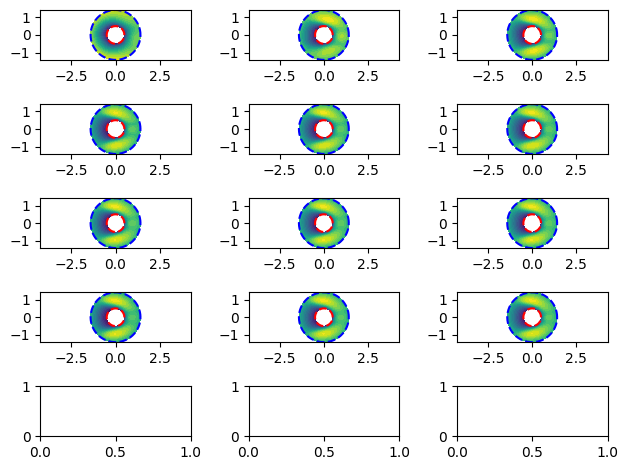

In [4]:
module = PINN(n_layers = 2)
lam_ = [10 * 2**k for k in range (12)]
fig, axes = plt.subplots( len(lam_)//3 +1,3)
axes = axes.flatten()
for i, lam in enumerate(lam_):
    train(module, params, f_1, lam = lam, N_colloc = 500, N_bord = 250)
    # Grille d'évaluation
    N_plot = 200
    x = np.linspace(-params.R, params.R, N_plot)
    y = np.linspace(-params.R, params.R, N_plot)
    XX, YY = np.meshgrid(x, y)

    # Évaluation du modèle sur la grille
    xy_grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
    with torch.no_grad():
        U = module(torch.tensor(xy_grid, dtype=torch.float32)).numpy().reshape(N_plot, N_plot)

    # Masque anneau
    rad = np.sqrt(XX**2 + YY**2)
    mask = (rad > params.r) & (rad < params.R)
    U[~mask] = np.nan
    ax = axes[i]
    # Plot
    theta = np.linspace(0, 2*np.pi, 300)
    ax.contourf(XX, YY, U, 20, cmap='viridis')
    ax.plot(params.r*np.cos(theta), params.r*np.sin(theta), 'r--', lw=1.5)
    ax.plot(params.R*np.cos(theta), params.R*np.sin(theta), 'b--', lw=1.5)
    ax.axis('equal')
    #ax.title(f'Solution PINN, lam = {lam}')
#fig.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
DEFAULTS = {
    "lr":          1e-3,
    "lam":         5.0,
    "hidden_size": 64,
    "n_layers":    4,
    "N_colloc":    200,
    "N_bord":      50,
}
N_list = np.asarray([10**(k) for k in range (1,5)])

results = mt.sensibilité_pinn(params  = params,
                                  hyper_params = {"lr":[1e-4, 1e-3, 1e-2],"lam":[1e-1, 1.0, 5.0, 10.0, 100],"N_colloc" : N_list,"N_bords": N_list/10 
                                                 },f = f_1,
                                  u_ref = None, max_epochs = 10_000,)


Convergence PINN : calcul de la solution de référence par FD sur une grille de 1000x1000 points...
Temps de calcul de la solution de référence : 17.16 secondes
Entrainement du PINN...
 Hyperparamètre : lr| valeurs : [0.0001, 0.001, 0.01]
-> lr = 0.0001 (autres : Défaut)
loss_finale = 0.15110856294631958err L_infty = 1.287e+00 temps = 18.2s
-> lr = 0.001 (autres : Défaut)
loss_finale = 0.009797225706279278err L_infty = 1.383e+00 temps = 18.2s
-> lr = 0.01 (autres : Défaut)
loss_finale = 0.039037980139255524err L_infty = 1.395e+00 temps = 18.6s
 Hyperparamètre : lam| valeurs : [0.1, 1.0, 5.0, 10.0, 100]
-> lam = 0.1 (autres : Défaut)
loss_finale = 0.0016639484092593193err L_infty = 1.373e+00 temps = 18.2s
-> lam = 1.0 (autres : Défaut)
